## tradycyjne determinmistyczne podejscie 

In [65]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

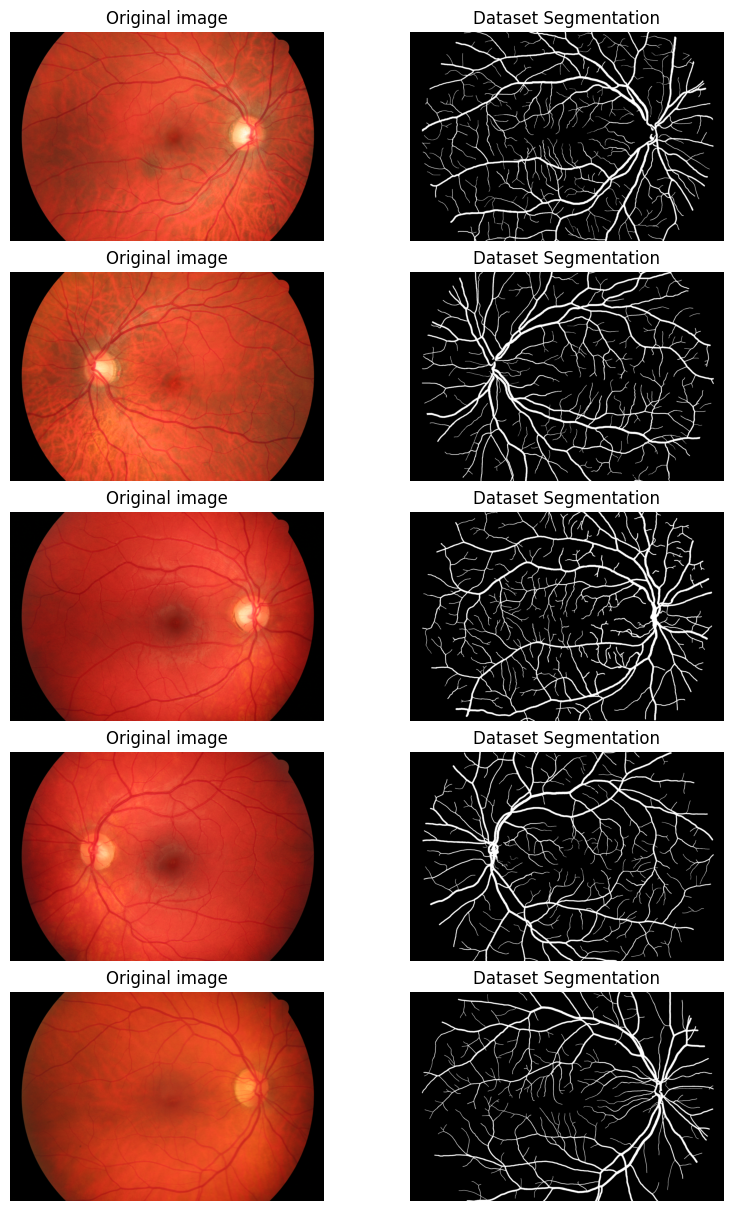

In [66]:
ds = [[],[]]
for i in range(1, 6):
    img = cv.imread(f"dataset/healthy/0{i}_h.jpg")
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    ds[0].append(img)
    img = cv.imread(f"dataset/healthy_manualsegm/0{i}_h.tif")
    ds[1].append(img)
ds = np.array(ds)


fig, axes = plt.subplots(5, 2, figsize=(8, 12), constrained_layout=True)
for i in range(5):
    axes[i, 0].imshow(ds[0][i])
    axes[i, 0].set_title("Original image")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(ds[1][i])
    axes[i, 1].set_title("Dataset Segmentation")
    axes[i, 1].axis("off")
plt.show()

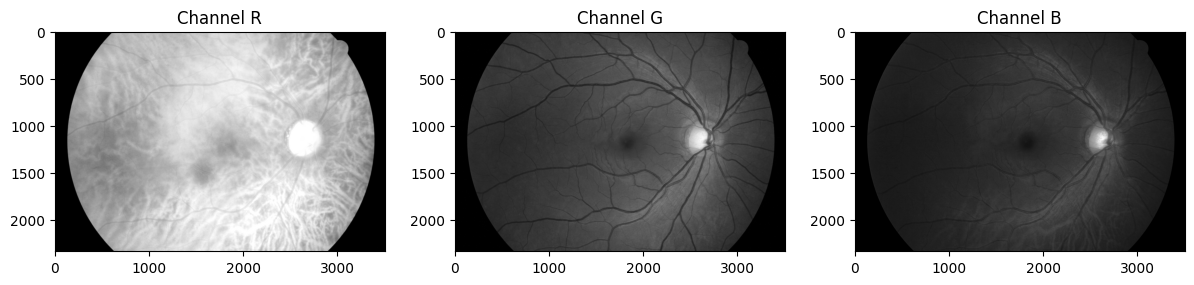

In [69]:
img = ds[0][0]

img_channel = cv.split(img) 
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for i in range(3):
    axes[i].set_title(f"Channel {['R', 'G', 'B'][i]}")
    axes[i].imshow(img_channel[i], cmap="gray")


naczynia najbardziej widoczne sa w kanale zielonym, wiec mozemy go wykorzystac do segmentacji.

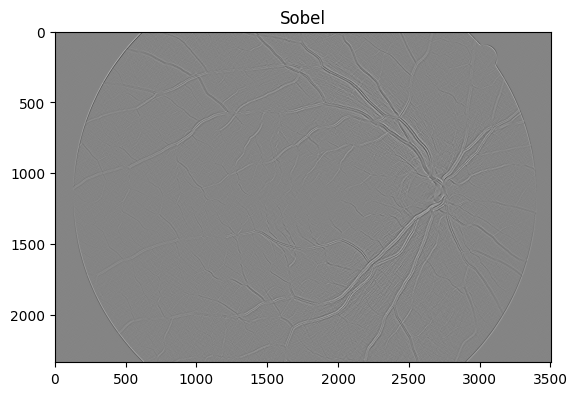

In [ ]:
img = []
img = cv.split(ds[0][0])[1]

plt.imshow(img, cmap="gray")




Sobel = cv.Sobel(img, cv.CV_64F, 1, 1,ksize=15)
plt.title("Sobel")
plt.imshow(Sobel, cmap="gray")



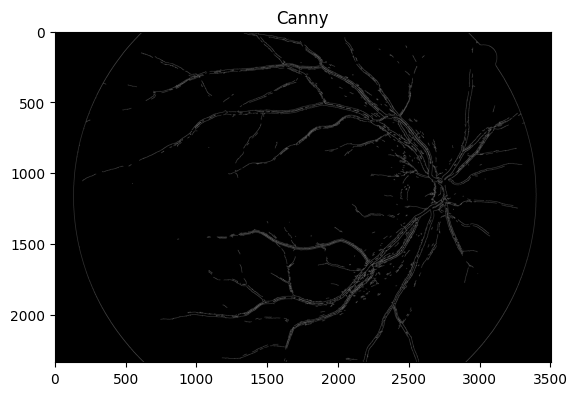

In [ ]:

plt.title("Canny")
canny = cv.Canny(img, 25, 60)
plt.imshow(canny, cmap="gray")


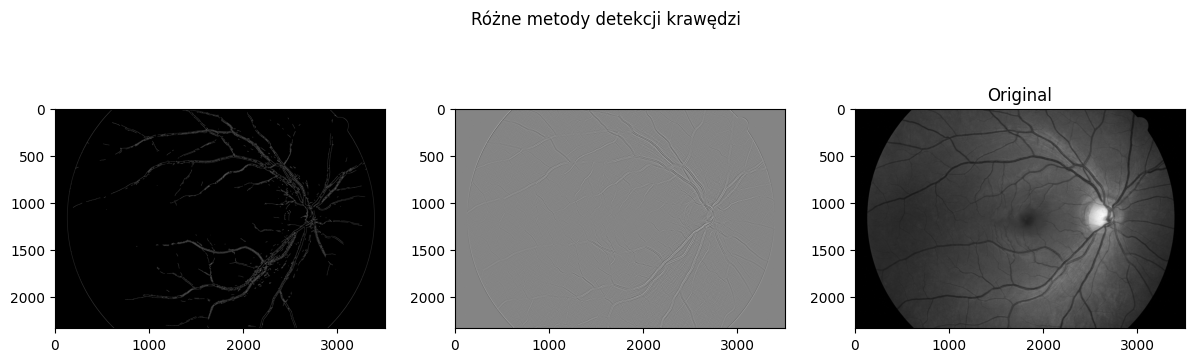

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
fig.suptitle("Różne metody detekcji krawędzi")
plt.title("Canny")
# canny = cv.Canny(img, 25, 60)
axes[0].imshow(canny, cmap="gray")
plt.title("Sobel")
# Sobel = cv.Sobel(img, cv.CV_64F, 1, 1,ksize=15)
axes[1].imshow(Sobel, cmap="gray")
plt.title("Original")
axes[2].imshow(img_channel[1], cmap="gray")
plt.show()

Metoda znnajdowania krawedzi cannego daje najlepsze rezultaty.

49.12671800087171


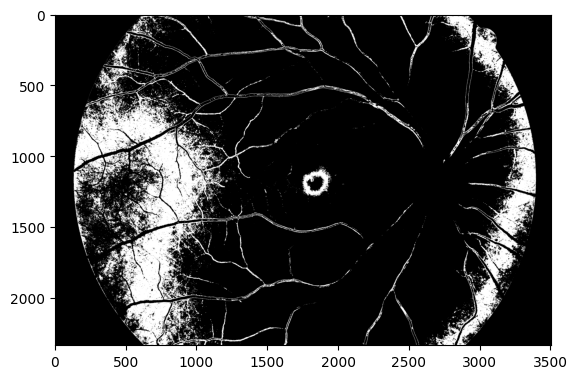

In [ ]:
kolor_naczyn = cv.mean(cv.GaussianBlur(img_channel[1], (5, 5), 0), mask=canny)[0]*0.7
print(kolor_naczyn) 
delta = 5

segmentation = np.zeros_like(img_channel[1])
segmentation[(img_channel[1] >= kolor_naczyn - delta) & (img_channel[1] <= kolor_naczyn + delta)] = 255
plt.imshow(segmentation, cmap="gray")

fatalny wynik, zmieniam podejście


In [ ]:
from collections import deque
import random

def region_growing(img, seed, threshold=10):
    h, w = img.shape
    visited = np.zeros((h, w), dtype=bool)
    region = np.zeros((h, w), dtype=np.uint8)

    seed_x, seed_y = seed
    seed_value = img[seed_x, seed_y]

    queue = deque()
    queue.append((seed_x, seed_y))
    visited[seed_x, seed_y] = True

    region[seed_x, seed_y] = 1

    # 4-neighborhood
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while queue:
        x, y = queue.popleft()

        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy

            if 0 <= nx < h and 0 <= ny < w and not visited[nx, ny]:
                if abs(int(img[nx, ny]) - int(seed_value)) <= threshold:
                    region[nx, ny] = 1
                    queue.append((nx, ny))

                visited[nx, ny] = True

    return region



# Region growing startuje tylko z pikseli wykrytych przez Canny
edge_points = np.column_stack(np.where(canny > 0))
if edge_points.size == 0:
    raise ValueError("Brak krawedzi z Canny - brak punktow startowych.")

# Opcjonalne odchudzenie punktow startowych, zeby bylo szybciej
max_seeds = 10
if len(edge_points) > max_seeds:
    step = max(1, len(edge_points) // max_seeds)
    edge_points = edge_points[::step]

combined_mask = np.zeros_like(img, dtype=np.uint8)
for x, y in edge_points:
    combined_mask |= region_growing(img, seed=(x, y), threshold=10)

plt.imshow(combined_mask, cmap="gray")
plt.title("Region growing from Canny edges")
plt.axis("off")


## to też fatalnie działa

ValueError: Brak krawedzi z Canny - brak punktow startowych.

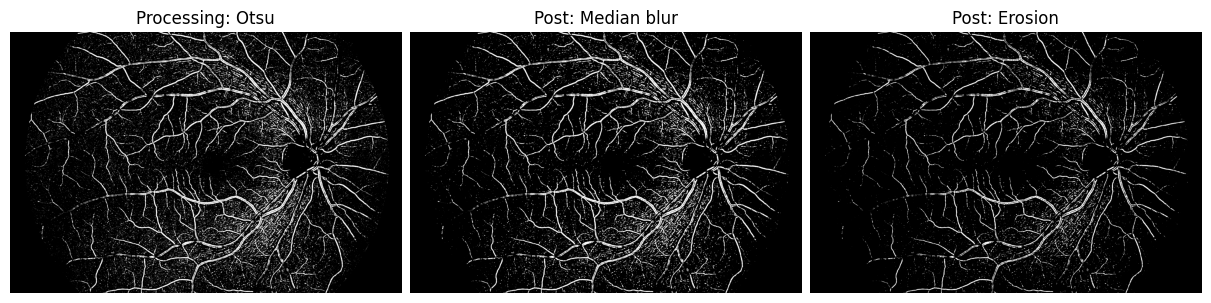

In [ ]:
clahe = cv.createCLAHE(clipLimit=1.8, tileGridSize=(10, 10))

enhanced = clahe.apply(img)

# top-hat
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (15, 15))
tophat = cv.morphologyEx(enhanced, cv.MORPH_BLACKHAT, kernel)

_, vessels = cv.threshold(tophat, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
vessels = np.array(vessels, dtype=np.uint8)

vessels_median = cv.medianBlur(vessels, 3)
vessels_eroded = cv.erode(
    vessels_median,
    cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3)),
    iterations=1,
 )

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
axes[0].set_title("Processing: Otsu")
axes[0].imshow(vessels, cmap="gray")
axes[0].axis("off")
axes[1].set_title("Post: Median blur")
axes[1].imshow(vessels_median, cmap="gray")
axes[1].axis("off")
axes[2].set_title("Post: Erosion")
axes[2].imshow(vessels_eroded, cmap="gray")
axes[2].axis("off")
plt.show()

Jak na tradycyjne podejscie jest to dla mnie wystarczający efekt, możnabyłoby pewnie pobawić się teraz bardziej floodfillem - mam taka ideę, że jeśli naczynie jest ciągłe i znajdziemy jego faktyczny kolor w jakims punkcie, to możemy wypełnić nim całe naczynie.

In [ ]:
# Porownanie maski eksperckiej z wynikiem pipeline (5 obrazow)
def pipeline_mask(img_rgb):
    img_green = cv.split(img_rgb)[1]
    clahe = cv.createCLAHE(clipLimit=1.8, tileGridSize=(10, 10))
    enhanced = clahe.apply(img_green)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (15, 15))
    tophat = cv.morphologyEx(enhanced, cv.MORPH_BLACKHAT, kernel)
    _, vessels = cv.threshold(tophat, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    vessels = np.array(vessels, dtype=np.uint8)
    vessels_median = cv.medianBlur(vessels, 3)
    vessels_eroded = cv.erode(
        vessels_median,
        cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3)),
        iterations=1,
    )
    return vessels_eroded

def bin_mask(mask):
    return (mask > 0).astype(np.uint8)

def metrics(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()
    tn = np.logical_and(np.logical_not(pred), np.logical_not(gt)).sum()
    fp = np.logical_and(pred, np.logical_not(gt)).sum()
    fn = np.logical_and(np.logical_not(pred), gt).sum()
    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    balance_arith = 0.5 * (sensitivity + specificity)
    balance_geom = np.sqrt(sensitivity * specificity)
    return accuracy, sensitivity, specificity, balance_arith, balance_geom

rows = []
for i in range(5):
    img_rgb = ds[0][i]
    pred = pipeline_mask(img_rgb)
    gt = cv.imread(f"dataset/healthy_manualsegm/0{i+1}_h.tif", cv.IMREAD_GRAYSCALE)
    if gt is None:
        raise FileNotFoundError("Brak pliku maski eksperckiej dla indeksu " + str(i+1))
    if gt.shape != pred.shape:
        gt = cv.resize(gt, (pred.shape[1], pred.shape[0]), interpolation=cv.INTER_NEAREST)
    pred_bin = bin_mask(pred)
    gt_bin = bin_mask(gt)
    accuracy, sensitivity, specificity, balance_arith, balance_geom = metrics(pred_bin, gt_bin)
    rows.append((i+1, accuracy, sensitivity, specificity, balance_arith, balance_geom))

print("idx\tAcc\tSens\tSpec\tBal_A\tBal_G")
for idx, accuracy, sensitivity, specificity, balance_arith, balance_geom in rows:
    print(
        f"{idx}\t{accuracy:.3f}\t{sensitivity:.3f}\t{specificity:.3f}\t"
        f"{balance_arith:.3f}\t{balance_geom:.3f}"
    )

avg = np.mean(np.array([r[1:] for r in rows]), axis=0)
print("avg\t" + "\t".join(f"{v:.3f}" for v in avg))

idx	Acc	Sens	Spec	Bal_A	Bal_G
1	0.927	0.433	0.983	0.708	0.652
2	0.923	0.522	0.967	0.744	0.710
3	0.893	0.495	0.940	0.717	0.682
4	0.918	0.479	0.964	0.721	0.679
5	0.863	0.548	0.894	0.721	0.700
avg	0.905	0.495	0.950	0.722	0.685


Z ciekawośic sprawdzam jesczy czy istnieje jakies lepsze parametry

In [ ]:
def pipeline_mask_params(img_rgb, clip_limit, tile_size, kernel_size):
    img_green = cv.split(img_rgb)[1]
    clahe = cv.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size, tile_size))
    enhanced = clahe.apply(img_green)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (kernel_size, kernel_size))
    tophat = cv.morphologyEx(enhanced, cv.MORPH_BLACKHAT, kernel)
    _, vessels = cv.threshold(tophat, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    vessels = np.array(vessels, dtype=np.uint8)
    vessels_median = cv.medianBlur(vessels, 3)
    vessels_eroded = cv.erode(
        vessels_median,
        cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3)),
        iterations=1,
    )
    return vessels_eroded

clip_limits = [3.9,4.0,4.1]
tile_sizes = [21,20]
kernel_sizes = [37,39,35]

best = None
for clip_limit in clip_limits:
    for tile_size in tile_sizes:
        for kernel_size in kernel_sizes:
            rows = []
            f1_scores = []
            for i in range(5):
                img_rgb = ds[0][i]
                pred = pipeline_mask_params(img_rgb, clip_limit, tile_size, kernel_size)
                gt = cv.imread(f"dataset/healthy_manualsegm/0{i+1}_h.tif", cv.IMREAD_GRAYSCALE)
                if gt is None:
                    raise FileNotFoundError("Brak pliku maski eksperckiej dla indeksu " + str(i+1))
                if gt.shape != pred.shape:
                    gt = cv.resize(gt, (pred.shape[1], pred.shape[0]), interpolation=cv.INTER_NEAREST)
                pred_bin = bin_mask(pred)
                gt_bin = bin_mask(gt)
                accuracy, sensitivity, specificity, balance_arith, balance_geom = metrics(pred_bin, gt_bin)
                rows.append((accuracy, sensitivity, specificity, balance_arith, balance_geom))
                pred_bool = pred_bin.astype(bool)
                gt_bool = gt_bin.astype(bool)
                tp = np.logical_and(pred_bool, gt_bool).sum()
                fp = np.logical_and(pred_bool, np.logical_not(gt_bool)).sum()
                fn = np.logical_and(np.logical_not(pred_bool), gt_bool).sum()
                precision = tp / (tp + fp + 1e-8)
                recall = tp / (tp + fn + 1e-8)
                f1 = 2 * precision * recall / (precision + recall + 1e-8)
                f1_scores.append(f1)

            avg = np.mean(np.array(rows), axis=0)
            avg_f1 = float(np.mean(f1_scores))
            score = avg_f1
            if best is None or score > best[0]:
                best = (score, clip_limit, tile_size, kernel_size, avg)

print("Best (F1):", best[0])
print("clipLimit, tileGridSize, kernel:", best[1], best[2], best[3])
print("Avg Acc, Sens, Spec, Bal_A, Bal_G:", " ".join(f"{v:.3f}" for v in best[4]))
print("Avg F1:", f"{best[0]:.3f}")

Best (F1): 0.7499752689756654
clipLimit, tileGridSize, kernel: 4.0 21 37
Avg Acc, Sens, Spec, Bal_A, Bal_G: 0.955 0.692 0.983 0.838 0.824
Avg F1: 0.750


Nie spodziewałem się aż takiej poprawy wyników, dzieki poszukiwaniom

 - Avg Acc 0.905 --> **0.955**
 - Sens 0.495 --> **0.692**
 - Spec 0.950 --> **0.983**
 - Bal_A 0.722 --> **0.838**
 - Bal_G 0.685 --> **0.824**

Best (F1): 0.7499752689756654
clipLimit, tileGridSize, kernel: 4.0 21 37

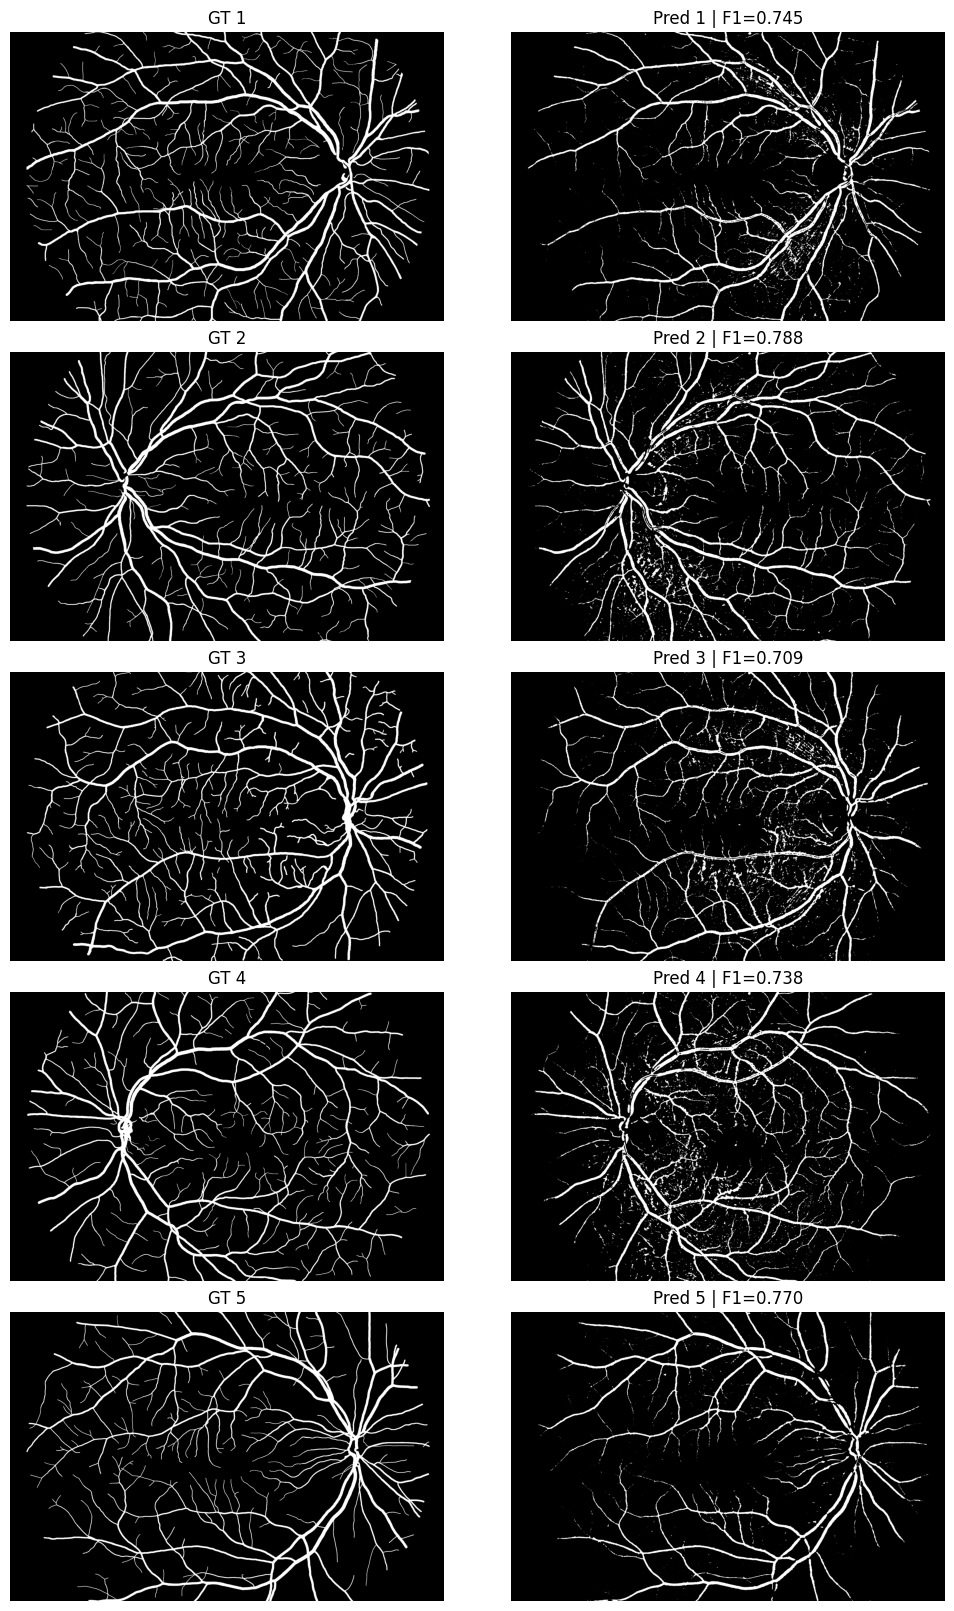

In [68]:
# Wizualizacja porownania dla params: clipLimit=4.0, tileGridSize=21, kernel=37
def pipeline_mask_params(img_rgb, clip_limit, tile_size, kernel_size):
    img_green = cv.split(img_rgb)[1]
    clahe = cv.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size, tile_size))
    enhanced = clahe.apply(img_green)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (kernel_size, kernel_size))
    tophat = cv.morphologyEx(enhanced, cv.MORPH_BLACKHAT, kernel)
    _, vessels = cv.threshold(tophat, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
    vessels = np.array(vessels, dtype=np.uint8)
    vessels_median = cv.medianBlur(vessels, 3)
    vessels_eroded = cv.erode(
        vessels_median,
        cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3)),
        iterations=1,
    )
    return vessels_eroded

def f1_score(pred_bin, gt_bin):
    pred_bool = pred_bin.astype(bool)
    gt_bool = gt_bin.astype(bool)
    tp = np.logical_and(pred_bool, gt_bool).sum()
    fp = np.logical_and(pred_bool, np.logical_not(gt_bool)).sum()
    fn = np.logical_and(np.logical_not(pred_bool), gt_bool).sum()
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    return 2 * precision * recall / (precision + recall + 1e-8)

clip_limit = 4.0
tile_size = 21
kernel_size = 37

fig, axes = plt.subplots(5, 2, figsize=(10, 16), constrained_layout=True)
for i in range(5):
    img_rgb = ds[0][i]
    pred = pipeline_mask_params(img_rgb, clip_limit, tile_size, kernel_size)
    gt = cv.imread(f"dataset/healthy_manualsegm/0{i+1}_h.tif", cv.IMREAD_GRAYSCALE)
    if gt is None:
        raise FileNotFoundError("Brak pliku maski eksperckiej dla indeksu " + str(i+1))
    if gt.shape != pred.shape:
        gt = cv.resize(gt, (pred.shape[1], pred.shape[0]), interpolation=cv.INTER_NEAREST)
    pred_bin = (pred > 0).astype(np.uint8)
    gt_bin = (gt > 0).astype(np.uint8)
    f1 = f1_score(pred_bin, gt_bin)
    axes[i, 0].imshow(gt_bin, cmap="gray")
    axes[i, 0].set_title(f"GT {i+1}")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(pred_bin, cmap="gray")
    axes[i, 1].set_title(f"Pred {i+1} | F1={f1:.3f}")
    axes[i, 1].axis("off")
plt.show()